### Data Cleaning

In [164]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [12]:
df = pd.read_csv("C:\\Users\\USER PC\\Downloads\\hospital_admissions_raw.csv", parse_dates= ['admission_date'])

In [14]:
#overview of the dataframe
print(df.shape)
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)

(1020, 10)
              age                 admission_date  length_of_stay  systolic_bp  \
count  970.000000                           1020      978.000000   956.000000   
mean    43.414433  2024-01-02 23:40:14.117647104        6.282515   125.573222   
min      1.000000            2023-01-01 00:00:00        0.000000    15.000000   
25%     21.000000            2023-07-14 00:00:00        1.500000   110.000000   
50%     44.000000            2023-12-27 00:00:00        3.600000   124.000000   
75%     64.750000            2024-07-07 00:00:00        7.000000   139.000000   
max     89.000000            2024-12-31 00:00:00      200.000000   270.000000   
std     25.993954                            NaN       15.725520    26.350793   

         hb_level  
count  941.000000  
mean    11.322317  
min     -1.000000  
25%      9.700000  
50%     11.400000  
75%     13.000000  
max     28.000000  
std      2.802361  
patient_id         0
age               50
gender            71
diagnosis       

In [17]:
#finding unique values for relevant columns
def unique_values(df, column):
    x = df[column].value_counts(dropna = False)
    print(x)

unique_values(df,'gender')
unique_values(df,'diagnosis')
unique_values(df,'ward')
unique_values(df,'outcome')

gender
Female    425
Male      359
M          86
F          79
NaN        71
Name: count, dtype: int64
diagnosis
HIV/AIDS               118
Malaria                118
Heart Failure          110
Hypertension           104
Tuberculosis           102
Pneumonia              102
Anemia                  98
Acute Kidney Injury     91
Sepsis                  90
Type 2 Diabetes         87
Name: count, dtype: int64
ward
Surgical     226
Medical      208
ICU          201
Pediatric    196
Maternity    189
Name: count, dtype: int64
outcome
Discharged    701
Referred      134
LAMA           96
Deceased       89
Name: count, dtype: int64


In [22]:
#drop the duplicate rows
df = df.drop_duplicates().copy()

In [23]:
#finding unique values for relevant columns
def unique_values(df, column):
    x = df[column].value_counts(dropna = False)
    print(x)

unique_values(df,'gender')
unique_values(df,'diagnosis')
unique_values(df,'ward')
unique_values(df,'outcome')

gender
Female    492
Male      439
NaN        69
Name: count, dtype: int64
diagnosis
HIV/AIDS               116
Malaria                113
Heart Failure          108
Hypertension           102
Pneumonia              101
Tuberculosis           100
Anemia                  97
Sepsis                  89
Acute Kidney Injury     87
Type 2 Diabetes         87
Name: count, dtype: int64
ward
Surgical     218
Medical      205
ICU          197
Pediatric    194
Maternity    186
Name: count, dtype: int64
outcome
Discharged    684
Referred      132
LAMA           95
Deceased       89
Name: count, dtype: int64


In [24]:
df.shape

(1000, 10)

In [25]:
#standardizing the gender column
gender_map = {
    "M": "Male",
    "F": "Female"}
df["gender"] = df["gender"].replace(gender_map)
df["gender"].value_counts(dropna=False)


gender
Female    492
Male      439
NaN        69
Name: count, dtype: int64

In [27]:
#dealing with outliers.

# define ranges
bp_min, bp_max   = 70, 220
hb_min, hb_max   = 3, 22
los_min, los_max = 0, 90

# flags
df["bp_outlier"]  = ~df["systolic_bp"].between(bp_min, bp_max)
df["hb_outlier"]  = ~df["hb_level"].between(hb_min, hb_max)
df["los_outlier"] = ~df["length_of_stay"].between(los_min, los_max)

# set implausible values to NaN, keep rows
df.loc[df["bp_outlier"],  "systolic_bp"]   = np.nan
df.loc[df["hb_outlier"],  "hb_level"]      = np.nan
df.loc[df["los_outlier"], "length_of_stay"] = np.nan


In [29]:
df.head(1000)

,patient_id,age,gender,diagnosis,admission_date,length_of_stay,systolic_bp,hb_level,ward,outcome,bp_outlier,hb_outlier,los_outlier
0,MRN0001,52.0,Female,Tuberculosis,2024-10-16,NaN,142.0,11.1,Medical,LAMA,False,False,True
1,MRN0002,NaN,Female,Acute Kidney Injury,2023-04-25,8.8,112.0,10.7,Surgical,Discharged,False,False,False
2,MRN0003,72.0,Female,HIV/AIDS,2023-01-26,1.7,101.0,8.9,Medical,Discharged,False,False,False
3,MRN0004,61.0,Female,Tuberculosis,2023-10-09,0.1,104.0,8.6,Medical,Discharged,False,False,False
4,MRN0005,21.0,Female,HIV/AIDS,2023-09-08,6.7,115.0,12.7,Maternity,Discharged,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MRN0996,18.0,Male,Heart Failure,2023-09-28,0.8,134.0,NaN,Pediatric,Discharged,False,True,False
996,MRN0997,40.0,Female,Anemia,2024-10-02,18.1,88.0,11.4,Medical,Discharged,False,False,False
997,MRN0998,72.0,Female,Malaria,2024-08-26,7.1,NaN,14.5,Pediatric,Discharged,True,False,False
998,MRN0999,39.0,Male,Malaria,2024-11-08,17.2,83.0,8.8,Surgical,Discharged,False,False,False


In [37]:
#filling up the null values
df['age'] = df['age'].fillna(df['age'].median())
df['systolic_bp'] = df['systolic_bp'].fillna(df.groupby('diagnosis')['systolic_bp'].transform("median"))
df['hb_level'] = df['hb_level'].fillna(df.groupby('diagnosis')['hb_level'].transform("median"))
df['length_of_stay'] = df['length_of_stay'].fillna(df.groupby('diagnosis')['length_of_stay'].transform("median"))

df["gender"] = df["gender"].fillna("Unknown")

In [38]:
df.isnull().sum()

patient_id        0
age               0
gender            0
diagnosis         0
admission_date    0
length_of_stay    0
systolic_bp       0
hb_level          0
ward              0
outcome           0
bp_outlier        0
hb_outlier        0
los_outlier       0
dtype: int64

## Simple Univariate EDA

In [41]:
#Basic overview of the cleaned dataframe
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(1000, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      1000 non-null   object        
 1   age             1000 non-null   float64       
 2   gender          1000 non-null   object        
 3   diagnosis       1000 non-null   object        
 4   admission_date  1000 non-null   datetime64[ns]
 5   length_of_stay  1000 non-null   float64       
 6   systolic_bp     1000 non-null   float64       
 7   hb_level        1000 non-null   float64       
 8   ward            1000 non-null   object        
 9   outcome         1000 non-null   object        
 10  bp_outlier      1000 non-null   bool          
 11  hb_outlier      1000 non-null   bool          
 12  los_outlier     1000 non-null   bool          
dtypes: bool(3), datetime64[ns](1), float64(4), object(5)
memory usage: 88.9+ KB
None
patient_id        0
ag

               age  length_of_stay  systolic_bp     hb_level
count  1000.000000      1000.00000  1000.000000  1000.000000
mean     43.408000         4.88295   124.732000    11.346850
std      25.314232         4.74908    19.663642     2.367923
min       1.000000         0.00000    70.000000     3.600000
25%      22.000000         1.50000   112.000000    10.000000
50%      44.000000         3.50000   124.000000    11.500000
75%      63.000000         6.70000   137.000000    12.800000
max      89.000000        34.00000   204.000000    19.400000


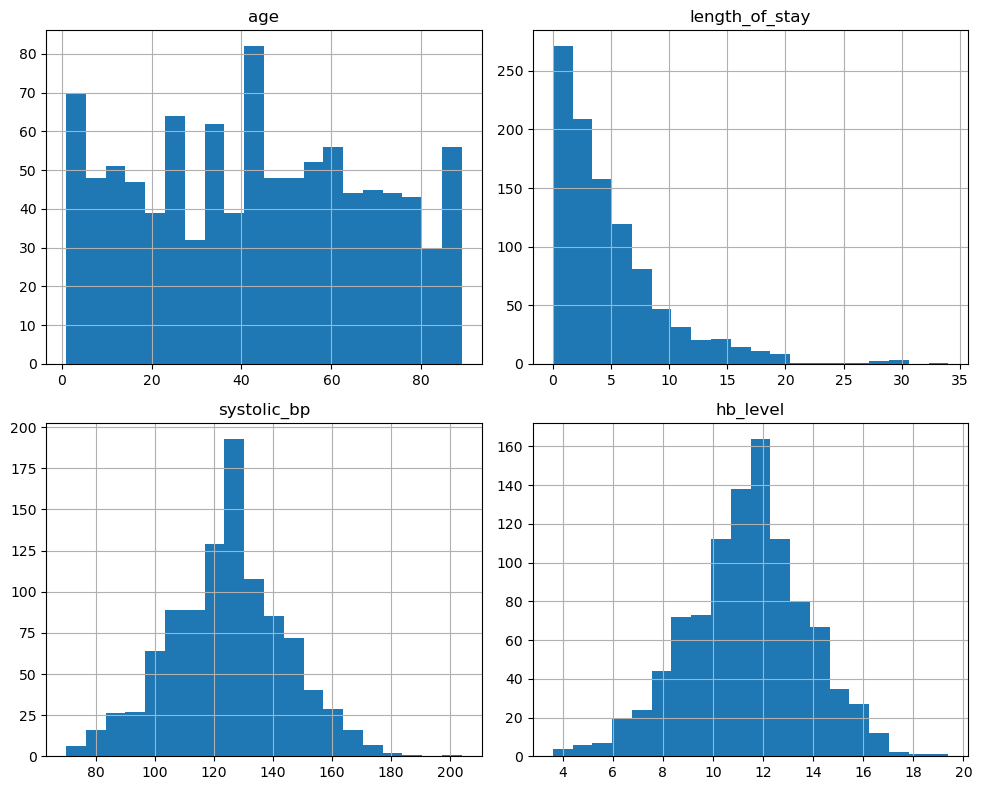

In [160]:
#univariate distributions. histograms for numeric columns
numeric_cols = ['age', 'length_of_stay', 'systolic_bp','hb_level']
def hist(df, col):
    print(df[col].describe())
    df[col].hist(bins = 20, figsize = (10,8))
    plt.tight_layout()
    plt.savefig(f"{col}_hist.png", dpi=300, bbox_inches="tight")
hist(df,numeric_cols)

summary_univariate = df[numeric_cols].describe()
summary_univariate.to_csv("Summary_univariate_variables.csv")


In [52]:
#univariate analysis of categorical columns
categoric_cols = ["gender", "diagnosis", "ward", "outcome"]
for col in categoric_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for gender:
gender
Female     492
Male       439
Unknown     69
Name: count, dtype: int64

Value counts for diagnosis:
diagnosis
HIV/AIDS               116
Malaria                113
Heart Failure          108
Hypertension           102
Pneumonia              101
Tuberculosis           100
Anemia                  97
Sepsis                  89
Acute Kidney Injury     87
Type 2 Diabetes         87
Name: count, dtype: int64

Value counts for ward:
ward
Surgical     218
Medical      205
ICU          197
Pediatric    194
Maternity    186
Name: count, dtype: int64

Value counts for outcome:
outcome
Discharged    684
Referred      132
LAMA           95
Deceased       89
Name: count, dtype: int64


In [55]:
#just the same, univariate analysis of categorical columns
cat_cols = ["gender", "diagnosis", "ward", "outcome"]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("Unique categories:", df[col].nunique(dropna=False))


=== gender ===
gender
Female     492
Male       439
Unknown     69
Name: count, dtype: int64
Unique categories: 3

=== diagnosis ===
diagnosis
HIV/AIDS               116
Malaria                113
Heart Failure          108
Hypertension           102
Pneumonia              101
Tuberculosis           100
Anemia                  97
Sepsis                  89
Acute Kidney Injury     87
Type 2 Diabetes         87
Name: count, dtype: int64
Unique categories: 10

=== ward ===
ward
Surgical     218
Medical      205
ICU          197
Pediatric    194
Maternity    186
Name: count, dtype: int64
Unique categories: 5

=== outcome ===
outcome
Discharged    684
Referred      132
LAMA           95
Deceased       89
Name: count, dtype: int64
Unique categories: 4


In [57]:
#proportional analysis of the categories in the categorical columns
for col in cat_cols:
    print(f"\n=== {col} (proportions) ===")
    print((df[col].value_counts(dropna=False) / len(df)).round(3) * 100)


=== gender (proportions) ===
gender
Female     49.2
Male       43.9
Unknown     6.9
Name: count, dtype: float64

=== diagnosis (proportions) ===
diagnosis
HIV/AIDS               11.6
Malaria                11.3
Heart Failure          10.8
Hypertension           10.2
Pneumonia              10.1
Tuberculosis           10.0
Anemia                  9.7
Sepsis                  8.9
Acute Kidney Injury     8.7
Type 2 Diabetes         8.7
Name: count, dtype: float64

=== ward (proportions) ===
ward
Surgical     21.8
Medical      20.5
ICU          19.7
Pediatric    19.4
Maternity    18.6
Name: count, dtype: float64

=== outcome (proportions) ===
outcome
Discharged    68.4
Referred      13.2
LAMA           9.5
Deceased       8.9
Name: count, dtype: float64


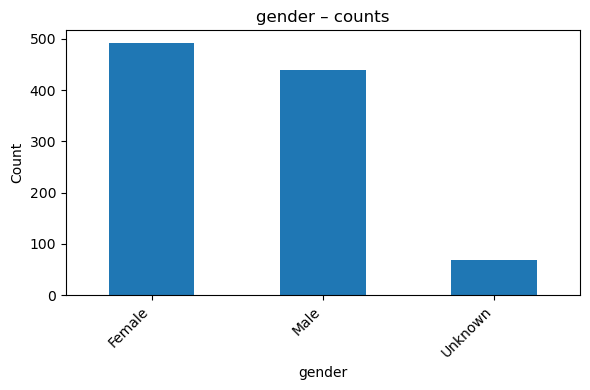

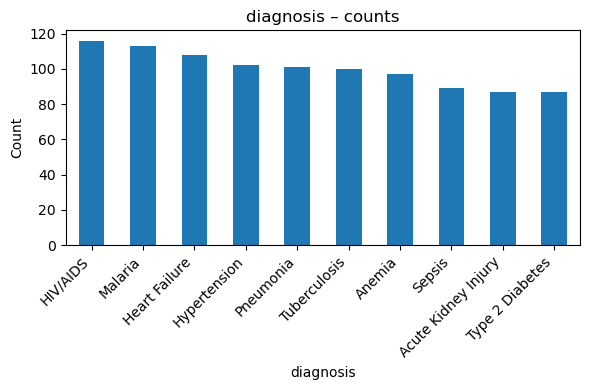

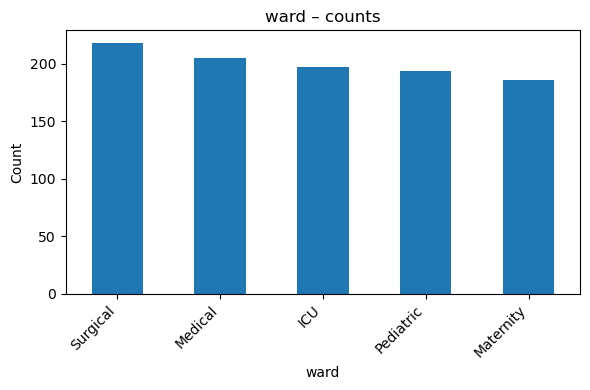

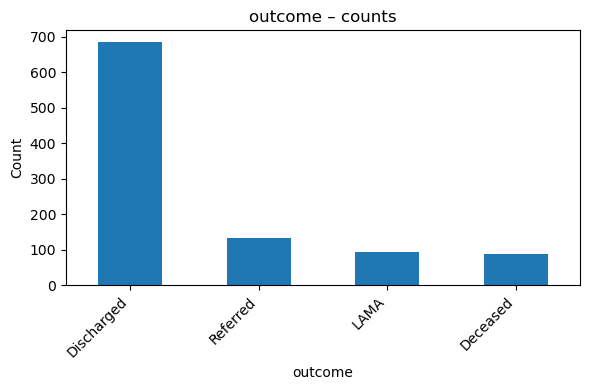

In [150]:
#relevant charts
cat_cols = ["gender", "diagnosis", "ward", "outcome"]
def bar (df, col):
    for col in cat_cols:
        plt.figure(figsize=(6, 4))
        df[col].value_counts(dropna=False).plot(kind="bar")
        plt.title(f"{col} – counts")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(f"{col}_hist.png", dpi=300, bbox_inches="tight")
        plt.show()
bar(df, cat_cols)

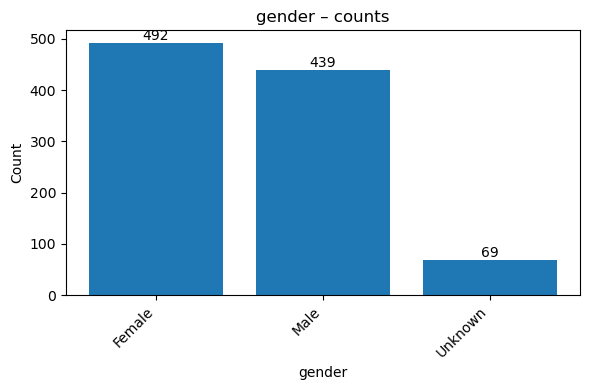

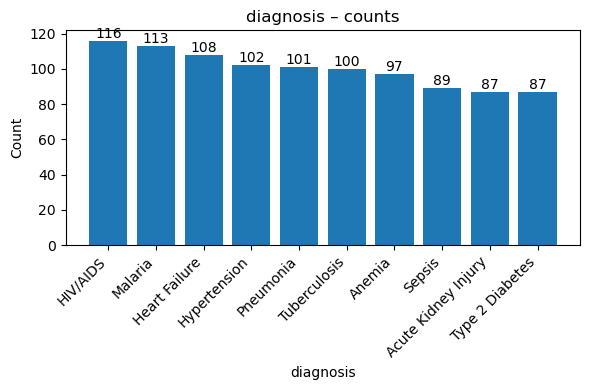

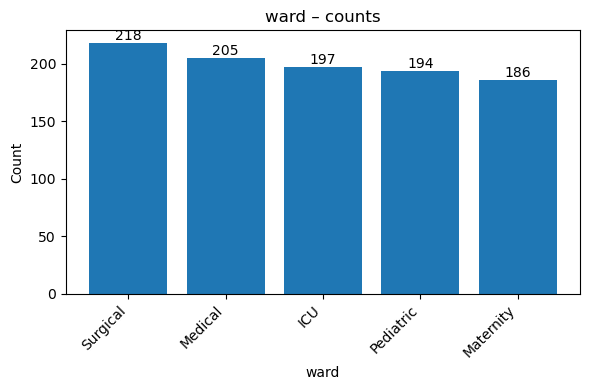

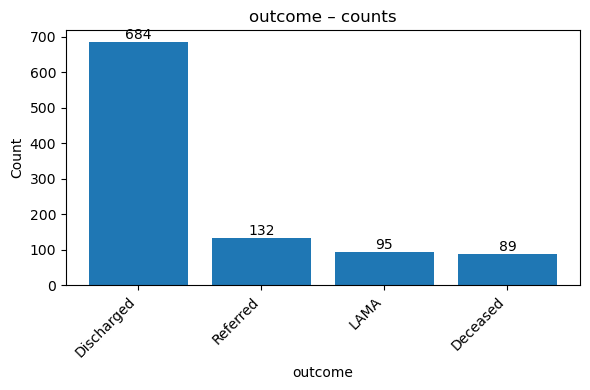

In [166]:
import matplotlib.pyplot as plt

cat_cols = ["gender", "diagnosis", "ward", "outcome"]

def bar_charts(df, cols):
    for col in cols:
        counts = df[col].value_counts(dropna=False)

        plt.figure(figsize=(6, 4))
        plt.bar(counts.index.astype(str), counts.values)

        plt.title(f"{col} – counts")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")

        # add value labels on top of bars
        for i, v in enumerate(counts.values):
            plt.text(i, v, str(v), ha="center", va="bottom")

        plt.tight_layout()
        plt.savefig(f"{col}_bar.png", dpi=300, bbox_inches="tight")
        plt.show()

bar_charts(df, cat_cols)


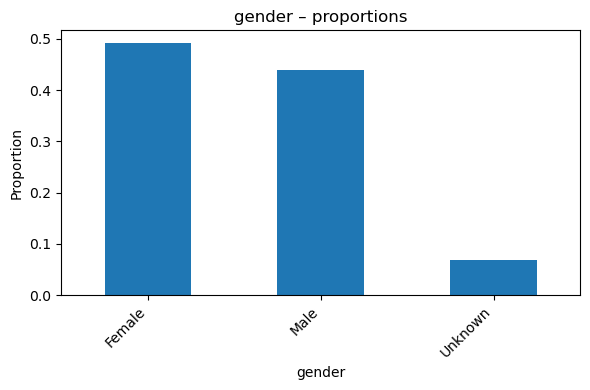

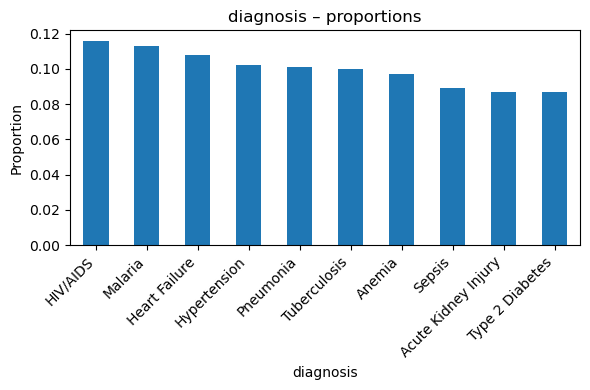

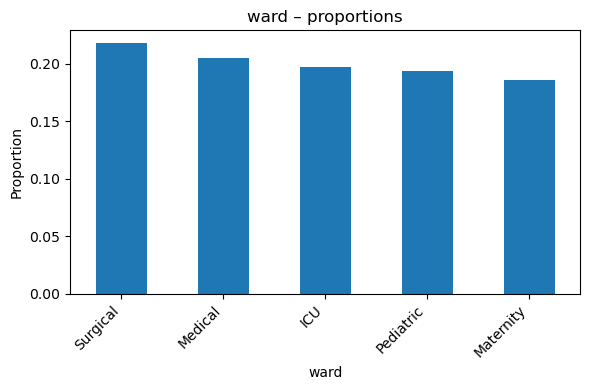

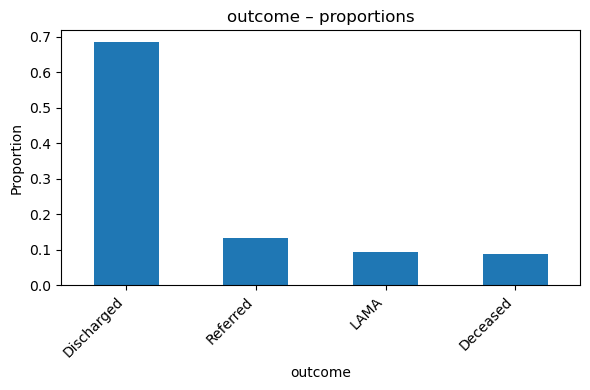

In [149]:
#relevant charts, but of proportions
def proportion (df, col):
    for col in cat_cols:
        plt.figure(figsize=(6, 4))
        (df[col].value_counts(dropna=False) / len(df)).plot(kind="bar")
        plt.title(f"{col} – proportions")
        plt.xlabel(col)
        plt.ylabel("Proportion")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(f"{col}_prop.png", dpi=300, bbox_inches="tight")
        plt.show()

proportion(df, cat_cols)

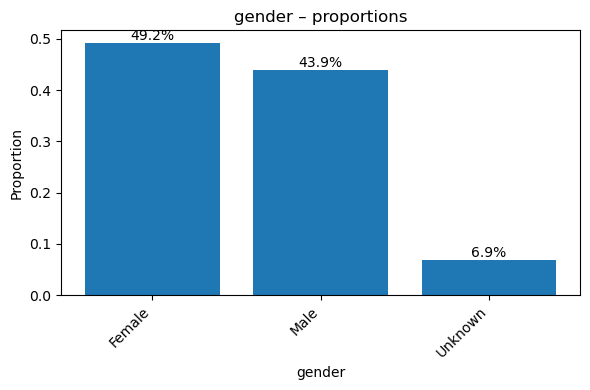

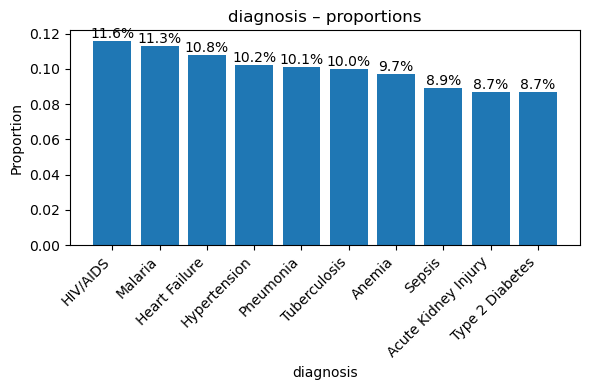

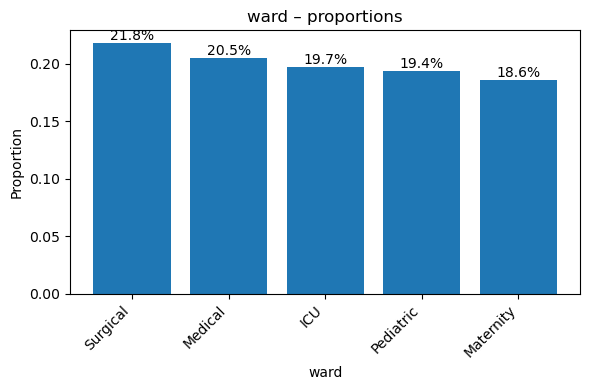

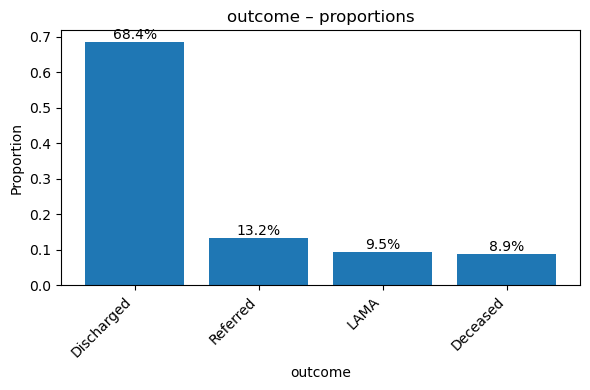

In [168]:
import matplotlib.pyplot as plt

cat_cols = ["gender", "diagnosis", "ward", "outcome"]

def proportion_bars(df, cols):
    for col in cols:
        props = df[col].value_counts(dropna=False) / len(df)

        plt.figure(figsize=(6, 4))
        plt.bar(props.index.astype(str), props.values)

        plt.title(f"{col} – proportions")
        plt.xlabel(col)
        plt.ylabel("Proportion")
        plt.xticks(rotation=45, ha="right")

        # add labels on top of bars (rounded proportions)
        for i, v in enumerate(props.values):
            plt.text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")

        plt.tight_layout()
        plt.savefig(f"{col}_prop.png", dpi=300, bbox_inches="tight")
        plt.show()

proportion_bars(df, cat_cols)


### Bivariate EDA

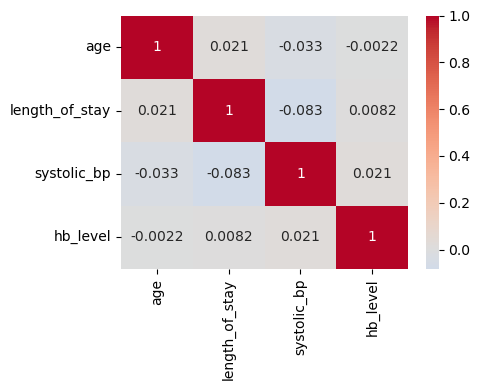

In [151]:
#bivariate analysis of numerical variables
num_cols = ["age", "length_of_stay", "systolic_bp", "hb_level"]
corr = df[num_cols].corr()
corr
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.tight_layout()
plt.savefig("Bivariate_heatmap.png", dpi = 300, bbox_inches = "tight")

In [85]:
los_by_dx = (
    df.groupby("diagnosis")["length_of_stay"]
      .agg(["median", "mean", "count",'min', 'max'])
      .sort_values("median", ascending=False)
)
los_by_dx


,median,mean,count,min,max
diagnosis,,,,,
Malaria,4.90,5.398230,113,0.0,19.8
Acute Kidney Injury,4.10,5.672414,87,0.1,30.2
Pneumonia,4.05,5.765842,101,0.2,29.5
Heart Failure,3.80,4.579630,108,0.0,18.1
Hypertension,3.50,4.911765,102,0.0,27.2
Tuberculosis,3.50,4.992000,100,0.0,19.9
Type 2 Diabetes,3.20,4.585057,87,0.1,16.6
Sepsis,3.10,5.377528,89,0.0,34.0
HIV/AIDS,2.70,3.551724,116,0.0,18.3


In [158]:
num_cols = ["age", "length_of_stay", "systolic_bp", "hb_level"]
cat_cols = ["gender", "diagnosis", "ward", "outcome"]

def num_vs_cat (df, cat_cols, num_cols):
    result = {}
    for cat in cat_cols:
        for num in num_cols:
            result[(cat, num)] = (df.groupby(cat)[num].agg(["median", "mean", "count",'min', 'max']))
    return result
results = num_vs_cat(df, cat_cols, num_cols)
results[("ward","systolic_bp")]

for (cat, num), table in results.items():
    filename = f"{cat}_vs_{num}_aggregate_data.csv"
    table.to_csv(filename)

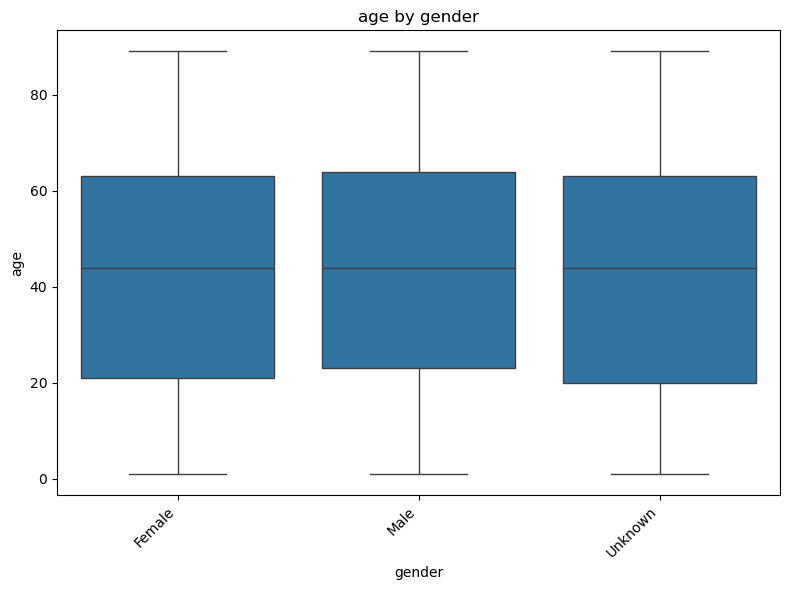

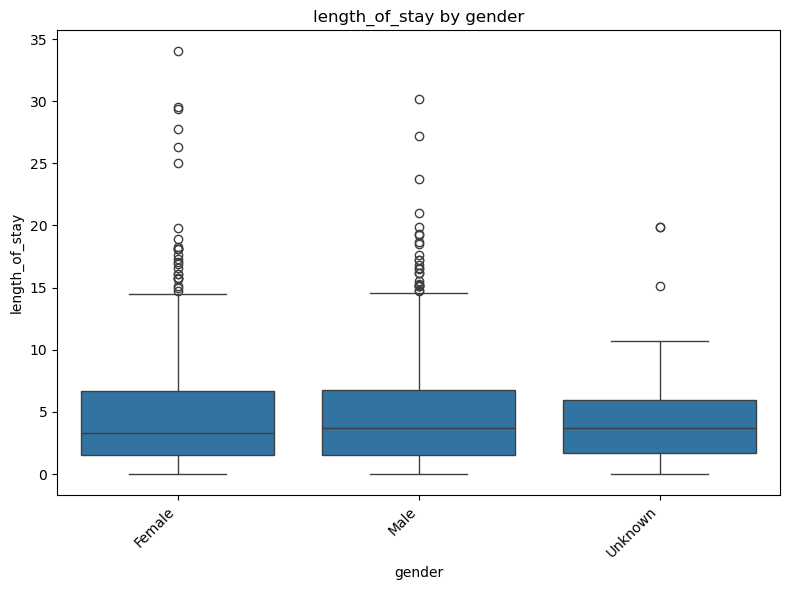

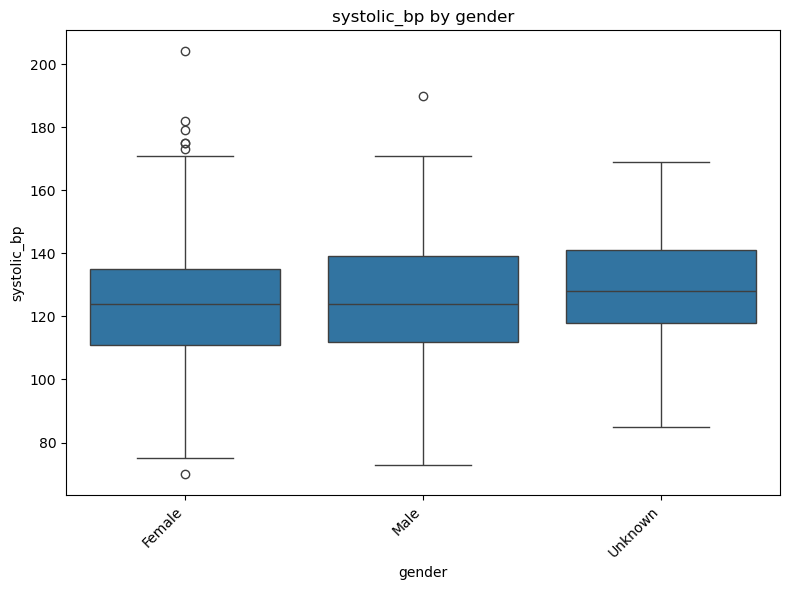

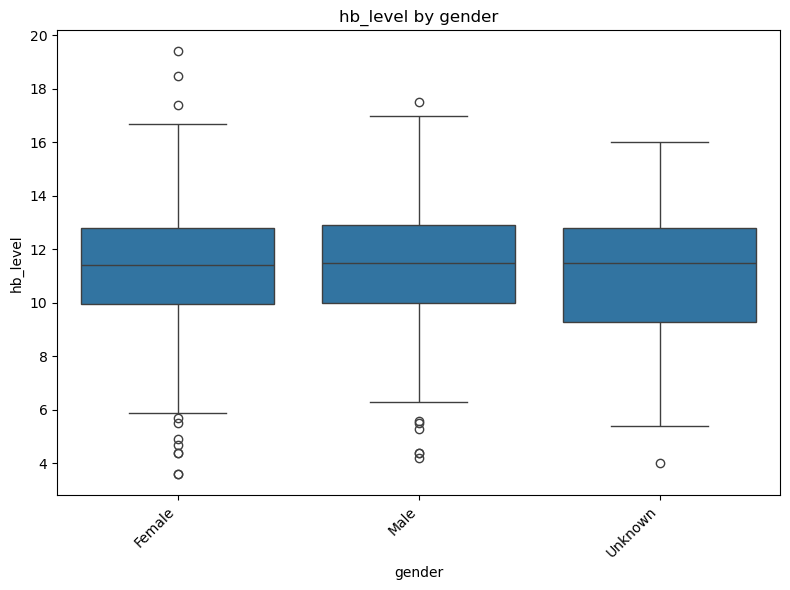

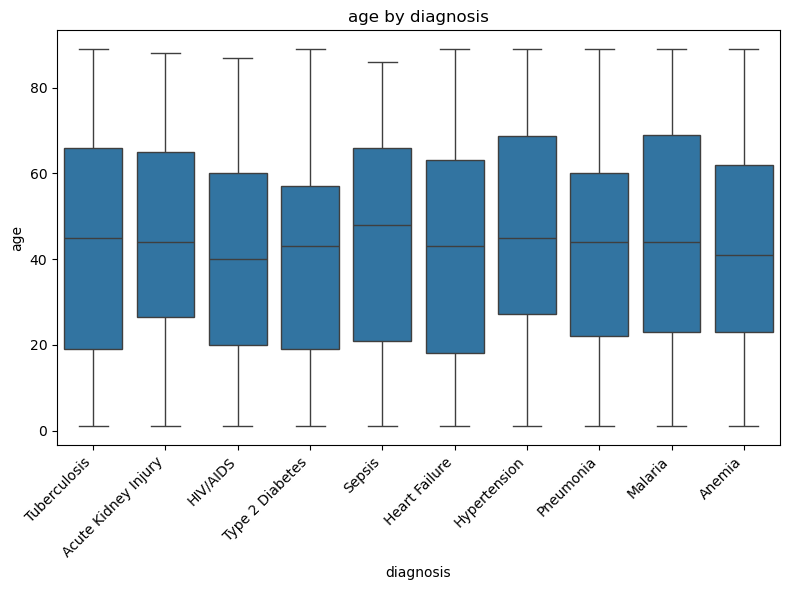

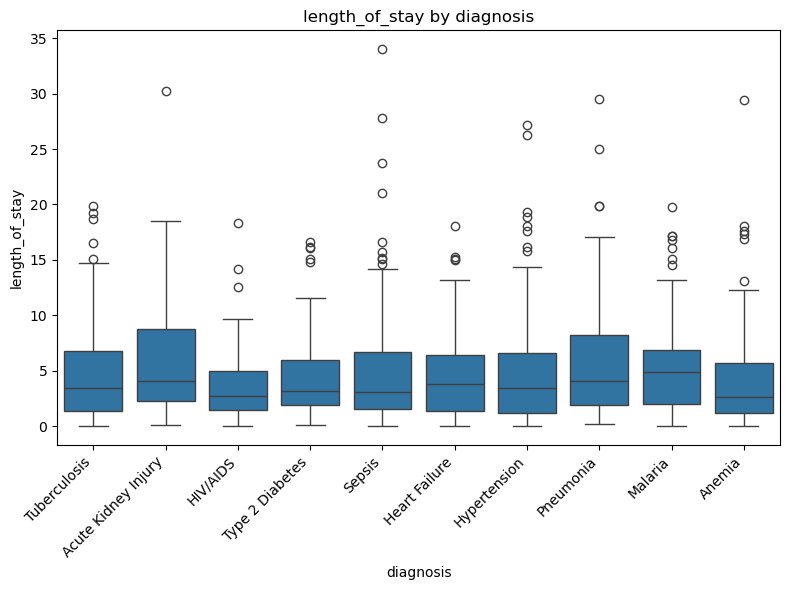

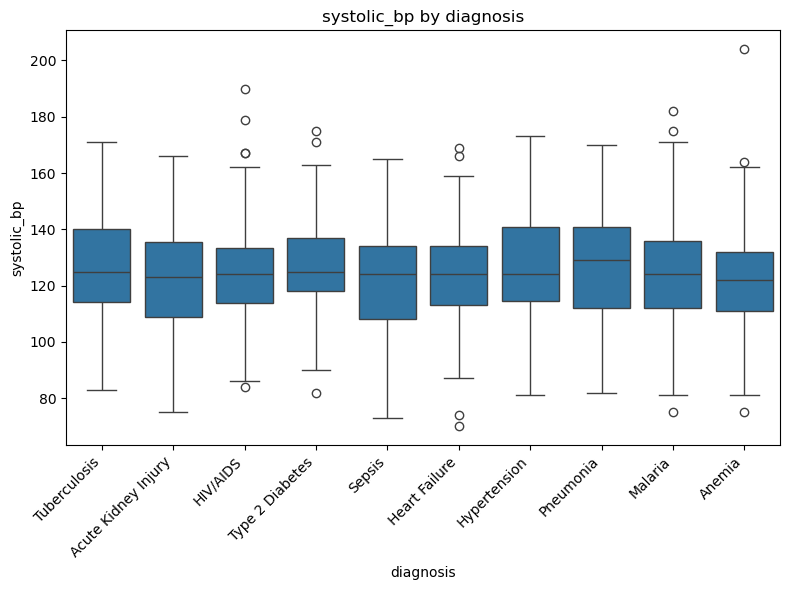

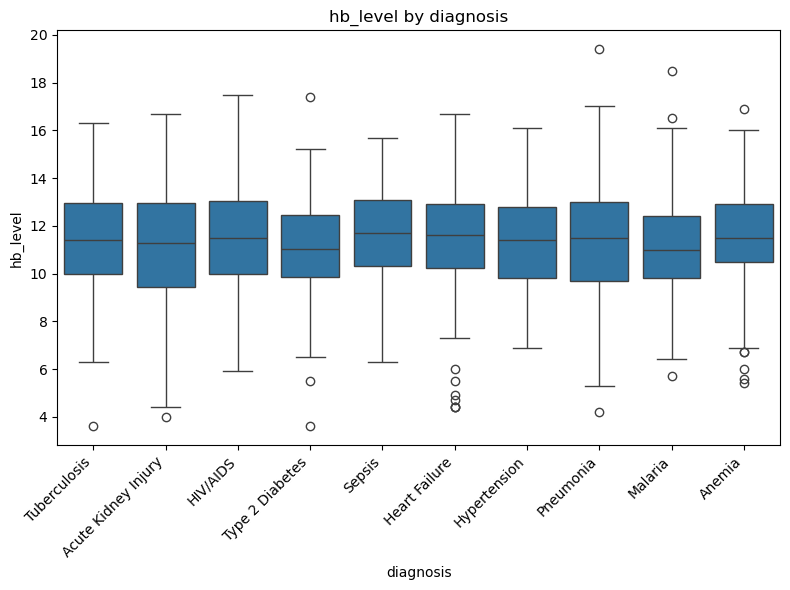

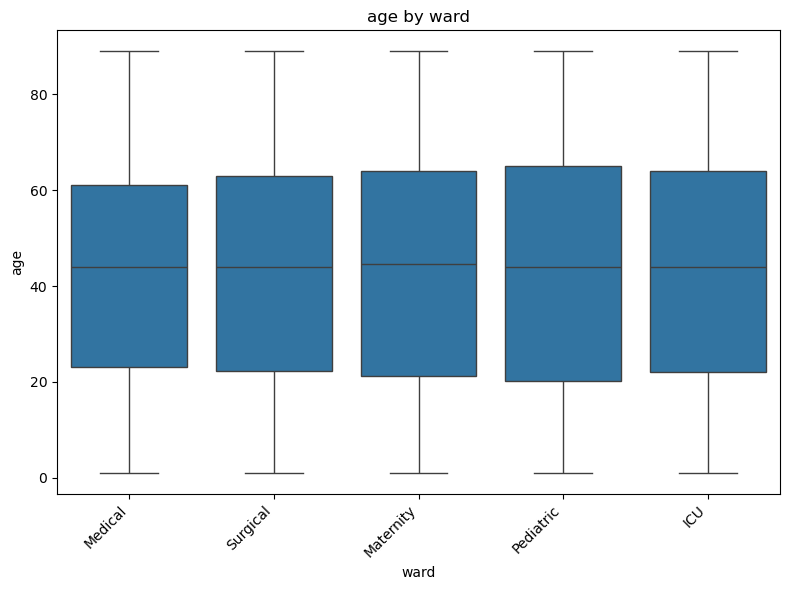

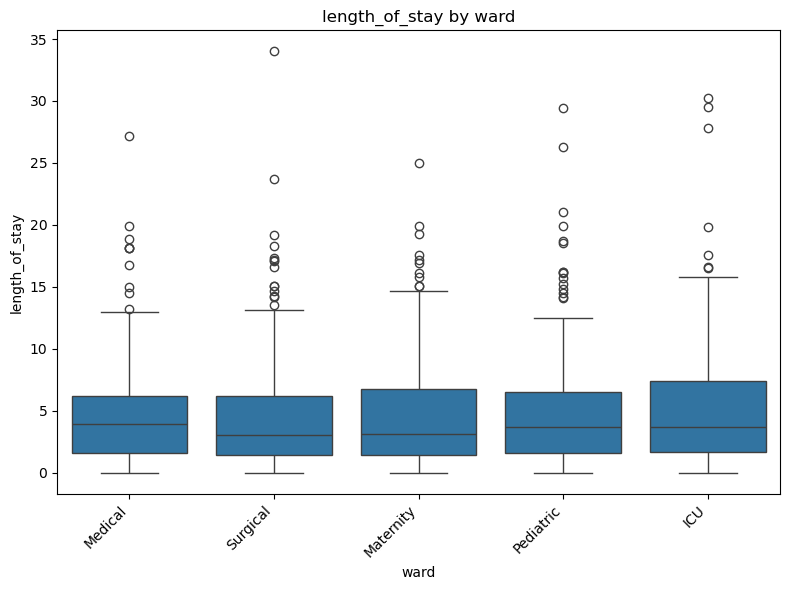

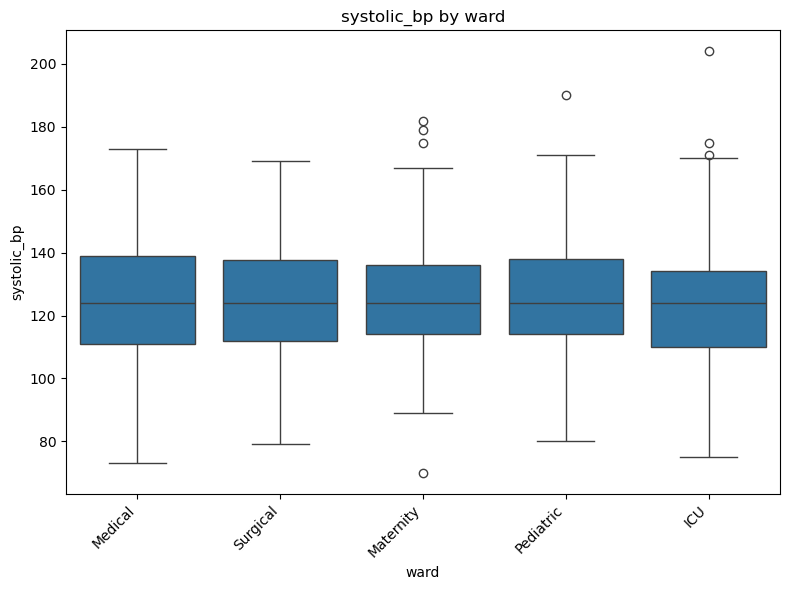

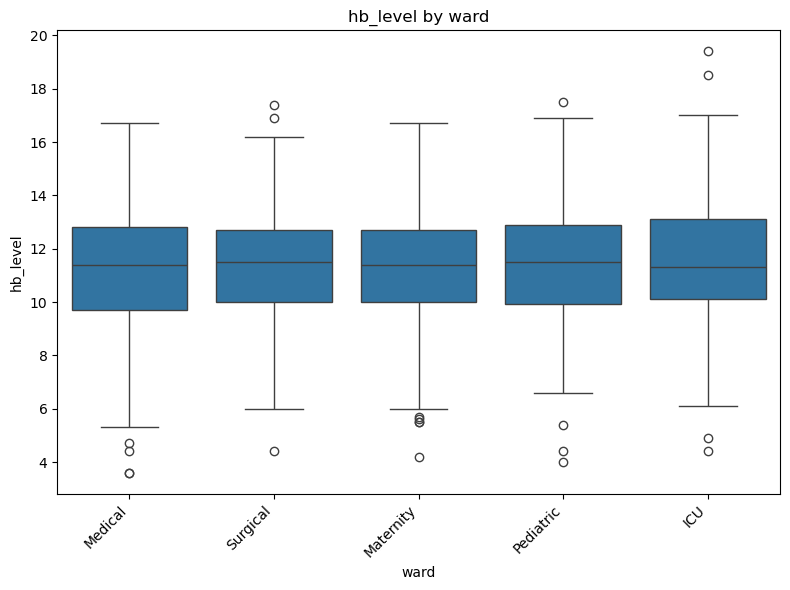

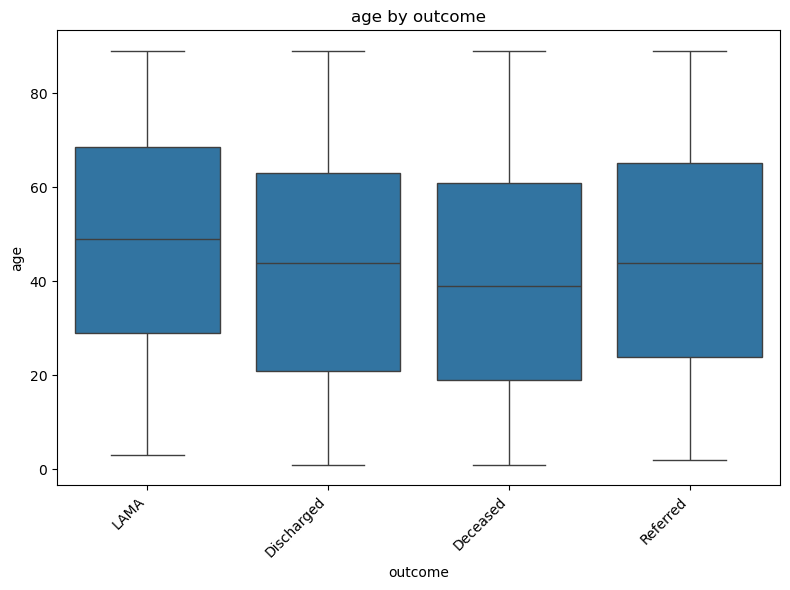

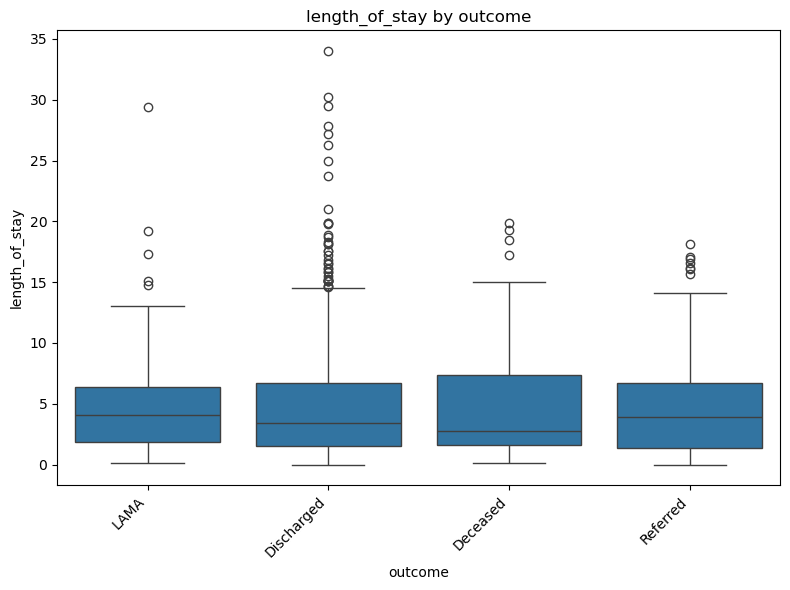

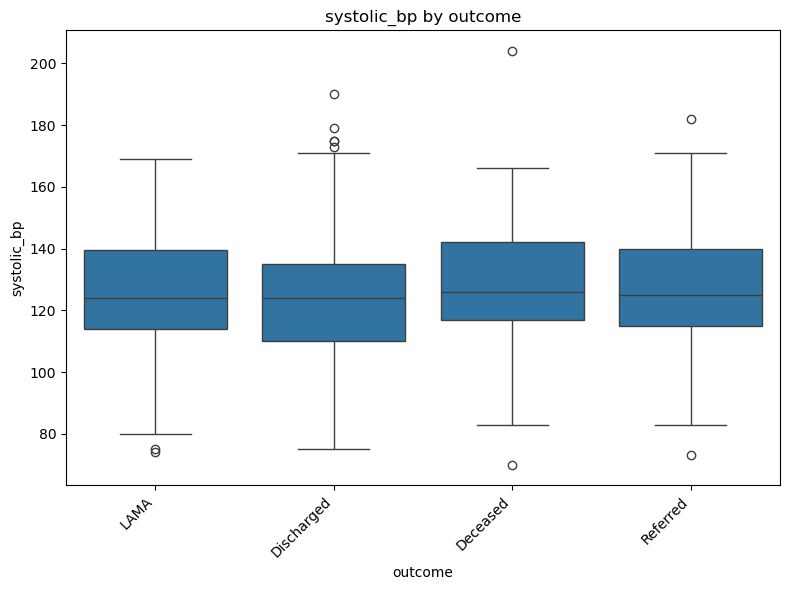

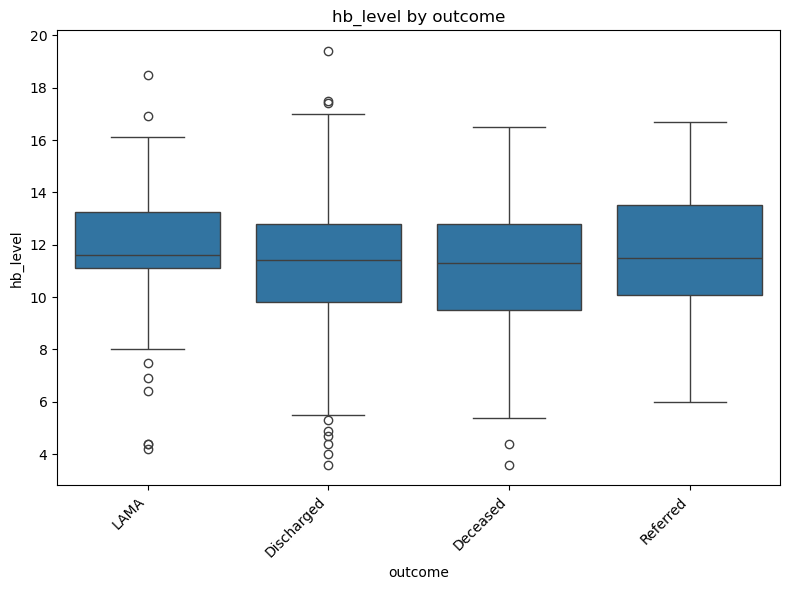

In [153]:
num_cols = ["age", "length_of_stay", "systolic_bp", "hb_level"]
cat_cols = ["gender", "diagnosis", "ward", "outcome"]

def boxplots (df, num_cols, cat_cols):
    for cat in cat_cols:
        for num in num_cols:
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df, x=cat, y=num)
            plt.title(f"{num} by {cat}")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.savefig(f"{cat}_vs_{num}_boxplot.png", dpi=300, bbox_inches="tight")
            plt.show()

boxplotting = boxplots(df, num_cols, cat_cols)

<Axes: title={'center': 'age by gender'}, xlabel='gender', ylabel='age'>

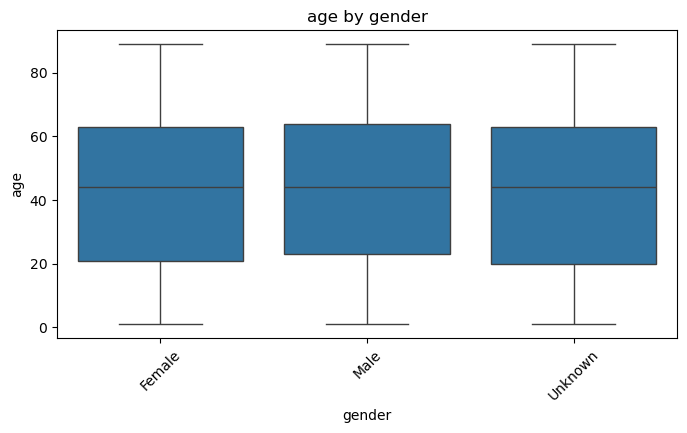

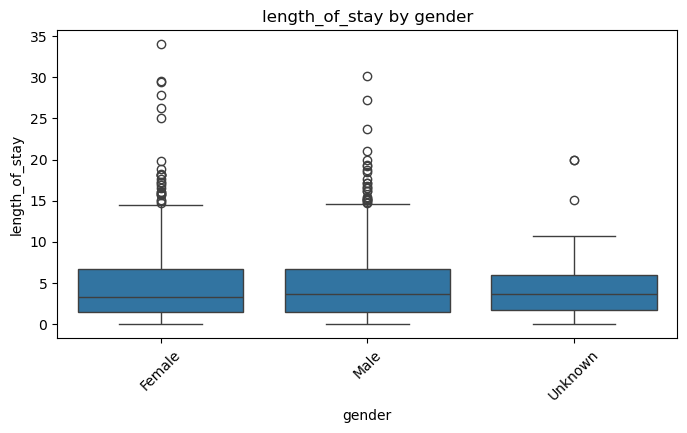

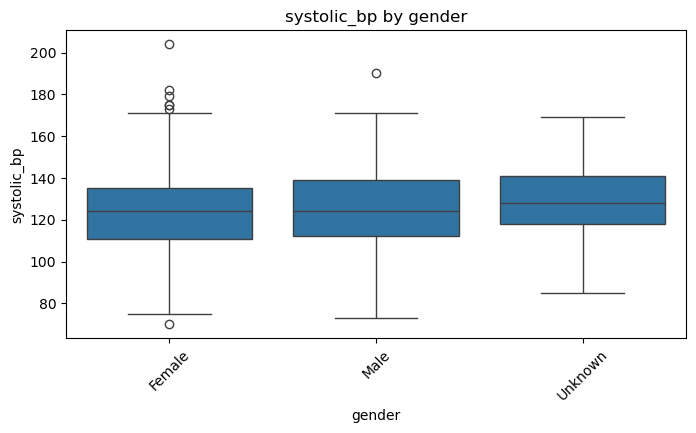

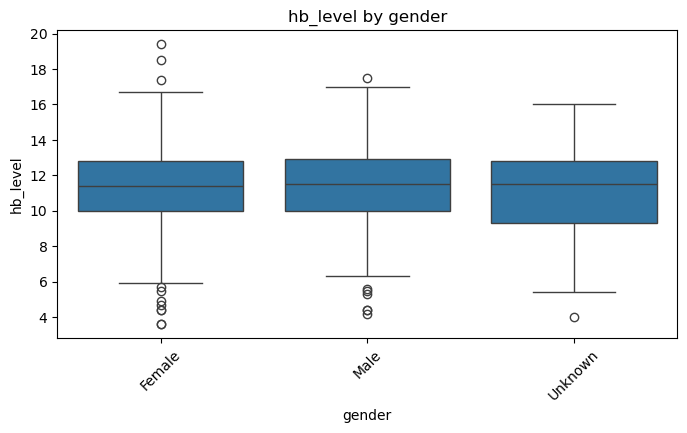

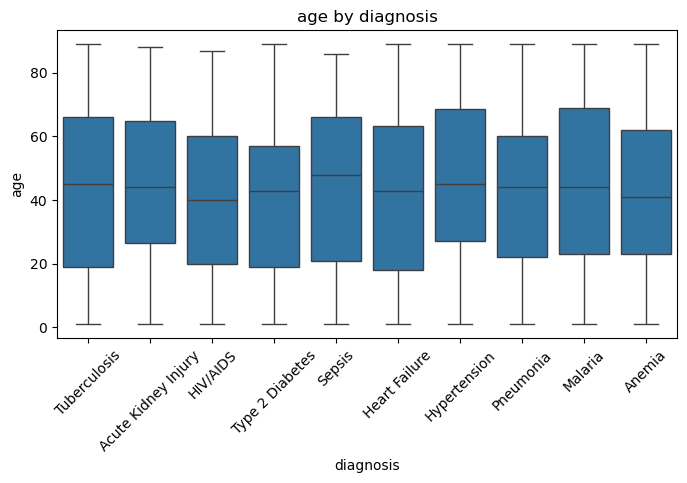

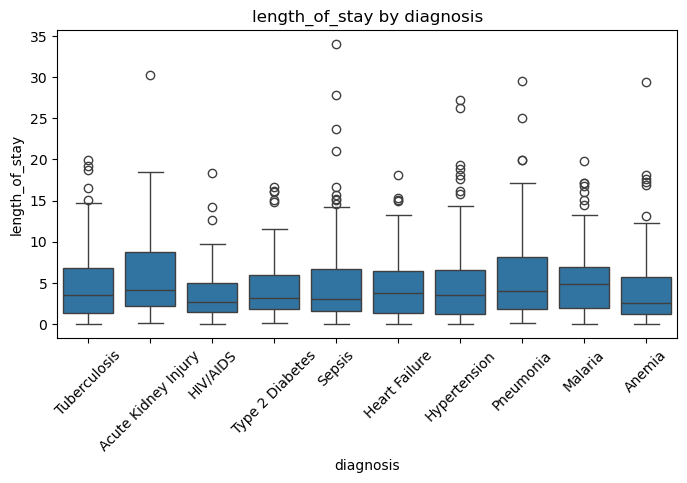

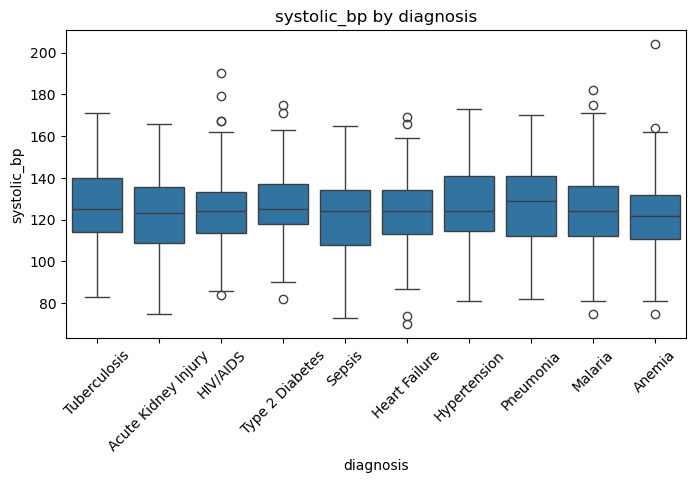

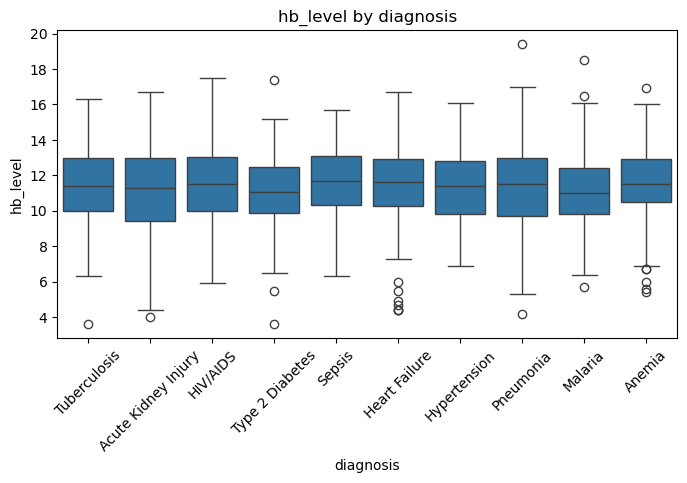

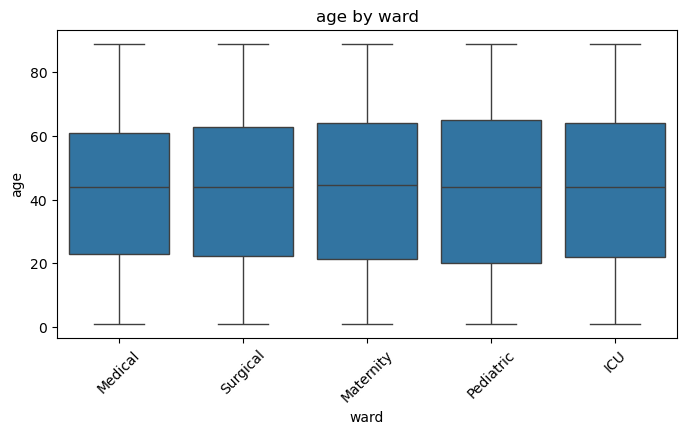

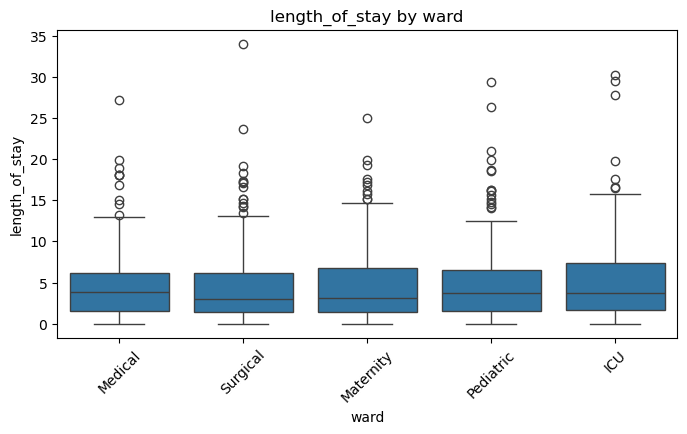

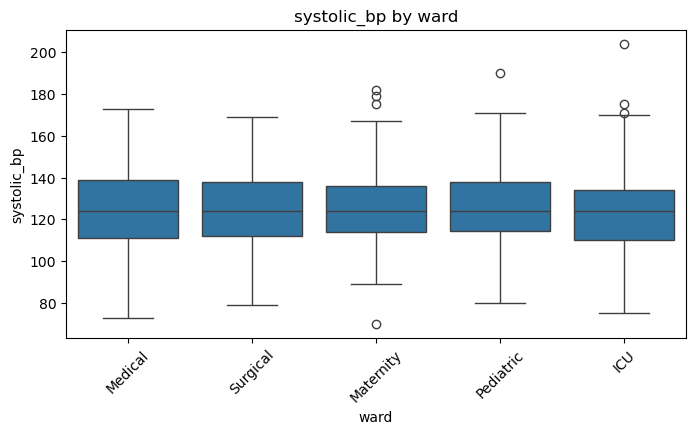

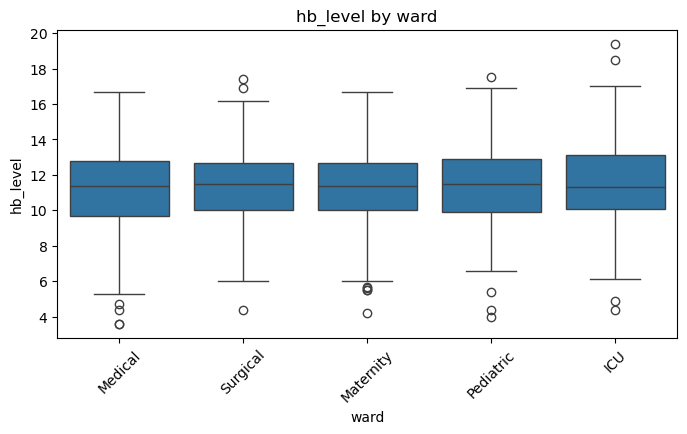

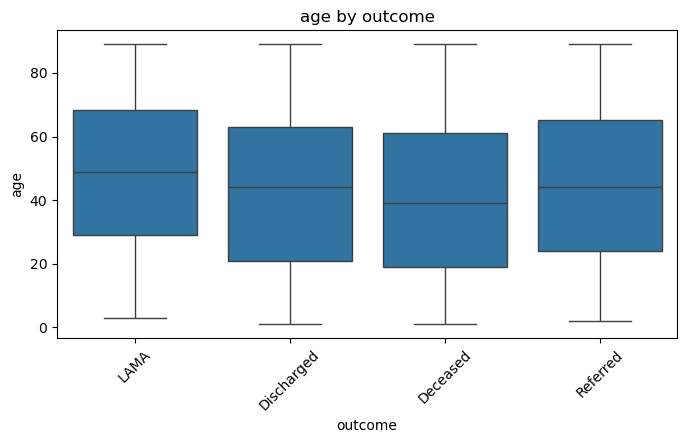

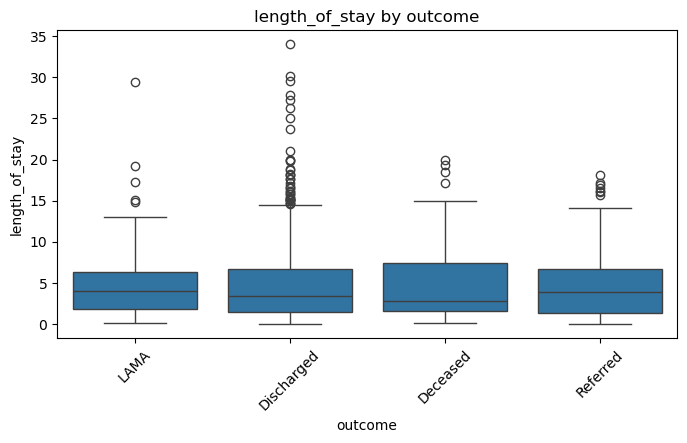

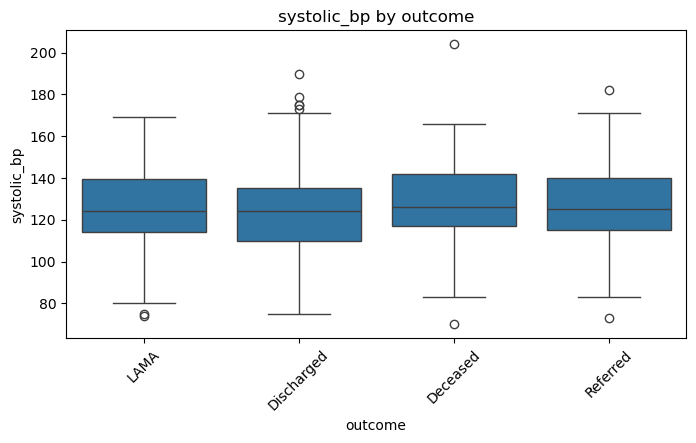

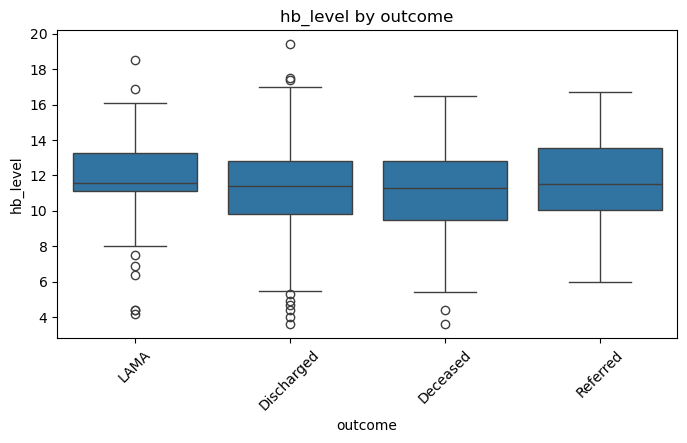

In [144]:
def boxplots_axes(df, num_cols, cat_cols):
    axes = {}
    for cat in cat_cols:
        for num in num_cols:
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.boxplot(data=df, x=cat, y=num, ax=ax)
            ax.set_title(f"{num} by {cat}")
            ax.tick_params(axis="x", rotation=45)
            axes[(num, cat)] = ax
    return axes

axes_dict = boxplots_axes(df, num_cols, cat_cols)
axes_dict[("age", "gender")]


In [154]:
cat_cols1 = ["gender", "diagnosis", "ward", "outcome"]
cat_cols2 = ["gender", "diagnosis", "ward", "outcome"]
def crosstabs (df, cat_cols1, cat_cols2):
    tabs = {}
    for cat1 in cat_cols1:
        for cat2 in cat_cols2:
            if cat1 == cat2:
                continue
            tabs[(cat1, cat2)] = pd.crosstab(df[cat1], df[cat2])
    return tabs

crosstab = crosstabs(df, cat_cols1, cat_cols2)
crosstab["gender",'ward']

ward,ICU,Maternity,Medical,Pediatric,Surgical
gender,,,,,
Female,85,99,107,101,100
Male,96,78,85,78,102
Unknown,16,9,13,15,16


In [155]:
def save_all_crosstabs(df, cat_cols, prefix="crosstab"):
    for i, cat1 in enumerate(cat_cols):
        for j, cat2 in enumerate(cat_cols):
            if j <= i:
                continue  # skip same and duplicate pairs

            counts = pd.crosstab(df[cat1], df[cat2])
            props  = pd.crosstab(df[cat1], df[cat2], normalize="index")

            counts.to_csv(f"{prefix}_{cat1}_vs_{cat2}_counts.csv")
            props.to_csv(f"{prefix}_{cat1}_vs_{cat2}_props.csv")

save_all_crosstabs(df, cat_cols)


In [165]:

# 1. Find all CSV files you want to combine
folder = r"C:\Users\USER PC\Downloads\EDA"
csv_files = glob.glob(os.path.join(folder, "*.csv"))
# 2. Write each CSV as a separate sheet in one Excel file
print("Found CSV files:", csv_files)  # quick sanity check

if not csv_files:
    raise ValueError("No CSV files found in the specified folder.")

output_path = os.path.join(folder, "eda_outputs.xlsx")

with pd.ExcelWriter(output_path) as writer:
    for file in csv_files:
        # sheet name = filename without path and extension, max 31 chars
        base = os.path.basename(file)
        sheet_name = os.path.splitext(base)[0][:31]

        df_tmp = pd.read_csv(file)
        df_tmp.to_excel(writer, sheet_name=sheet_name, index=False)

Found CSV files: ['C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_diagnosis_vs_outcome_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_diagnosis_vs_outcome_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_diagnosis_vs_ward_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_diagnosis_vs_ward_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_diagnosis_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_diagnosis_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_outcome_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_outcome_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_ward_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_gender_vs_ward_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_ward_vs_outcome_counts.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\crosstab_ward_vs_outcome_props.csv', 'C:\\Users\\USER PC\\Downloads\\EDA\\diagnosis_vs_age_aggregate_

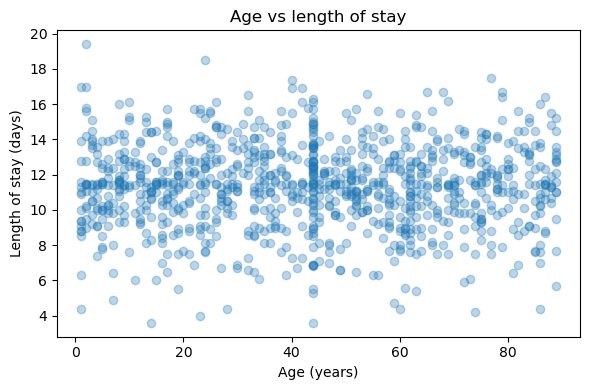

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["age"], df["hb_level"], alpha=0.3)
plt.xlabel("Age (years)")
plt.ylabel("Length of stay (days)")
plt.title("Age vs length of stay")
plt.tight_layout()
#plt.savefig("age_vs_los_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


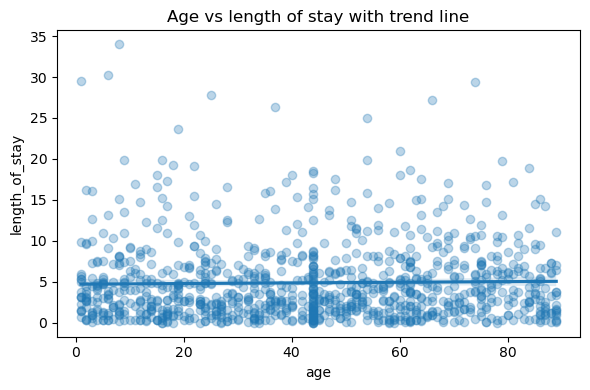

In [170]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x="age", y="length_of_stay", scatter_kws={"alpha": 0.3})
plt.title("Age vs length of stay with trend line")
plt.tight_layout()
#plt.savefig("age_vs_los_regplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [174]:
long_stays = df[df["length_of_stay"] >=20]
long_stays

,patient_id,age,gender,diagnosis,admission_date,length_of_stay,systolic_bp,hb_level,ward,outcome,bp_outlier,hb_outlier,los_outlier
206,MRN0207,19.0,Male,Sepsis,2023-08-05,23.7,123.0,12.9,Surgical,Discharged,False,False,False
259,MRN0260,37.0,Female,Hypertension,2023-12-29,26.3,121.0,9.8,Pediatric,Discharged,False,False,False
306,MRN0307,54.0,Female,Pneumonia,2023-10-20,25.0,124.0,13.6,Maternity,Discharged,False,False,False
397,MRN0398,60.0,Male,Sepsis,2023-09-28,21.0,115.0,12.3,Pediatric,Discharged,False,False,False
771,MRN0772,74.0,Female,Anemia,2024-01-20,29.4,94.0,13.6,Pediatric,LAMA,False,False,False
865,MRN0866,25.0,Female,Sepsis,2023-09-07,27.8,103.0,15.5,ICU,Discharged,False,False,False
872,MRN0873,8.0,Female,Sepsis,2024-06-27,34.0,134.0,11.6,Surgical,Discharged,False,False,False
877,MRN0878,6.0,Male,Acute Kidney Injury,2023-12-27,30.2,83.0,9.1,ICU,Discharged,False,False,False
913,MRN0914,66.0,Male,Hypertension,2024-07-20,27.2,146.0,12.8,Medical,Discharged,False,False,False
972,MRN0973,1.0,Female,Pneumonia,2023-06-10,29.5,150.0,10.9,ICU,Discharged,False,False,False
